# 00 - Inicijalno upoznavanje dataseta
Pre bilo kakve EDA želimo da upoznamo sirove podatke i
proverimo pretpostavke koje utiču na učitavanje i pripremu (npr. u kom formatu su
maske). Dakle, proveravamo strukturu i format: koliko fajlova, kako se slike i maske uparuju, kako su kodirane, i da li ima duplikata.

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir()) # root repoa koristimo kako bismo mogli da radimo importe iz src modula
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
from PIL import Image
from scipy import ndimage
from src.config import IMG_DIR, MASK_DIR
from src.utils import show_image_mask_and_overlay
from collections import Counter

## 1. Struktura foldera i broj fajlova
Očekujemo 283 slike i 283 maske (par za svaku sliku). Proveravamo da nema
nedostajućih ili viška fajlova.

In [2]:
imgs = sorted(p.name for p in IMG_DIR.glob("*.png"))
masks = sorted(p.name for p in MASK_DIR.glob("*.png"))
print("slika:", len(imgs), "maski:", len(masks))

slika: 283 maski: 283


## 2. Uparivanje slika i maski
Za loader je bitno kako spojiti sliku sa njenom maskom. Zato proveravamo da li su nazivi
fajlova isti u oba foldera, pa će uparivanje biti trivijalno.

In [3]:
all_pngs = sorted(set(imgs) & set(masks))
print("identičnih naziva:", len(all_pngs))
print("slike bez maske:", set(imgs)-set(masks))
print("maske bez slike:", set(masks)-set(imgs))

identičnih naziva: 283
slike bez maske: set()
maske bez slike: set()


Zaključujemo da svaka slika ima odgovarajuću masku i da im se nazivi poklapaju, te će nam uparivanje biti lako.

## 3. Format slika i maski iz dataseta

Proveravamo broj kanala, bit depth i opseg vrednosti.

Zvanični opis dataseta kaže: 283 slike rezolucije 1600×1200 (preseci mišjeg mozga
snimljeni fluorescentnim mikroskopom), a oznake su nastale hibridno (poluautomatska + ručna semantička segmentacija) i rezultat su *„black (0) and white (255) images having pixel-level annotations"*.

Prema opisu očekujemo da vidimo:
- slika = RGB uint8 (0–255)
- maska = jednokanalna uint8 sa tačno dve vrednosti {0, 255}. 

Proveravamo da li fajlovi to potvrđuju jer ove činjenice utiču na pripremu podataka.

In [4]:
def description(p):
    im = Image.open(p); a = np.array(im)
    return dict(mode=im.mode, dtype=str(a.dtype), shape=a.shape, min=int(a.min()), max=int(a.max()))
ex = imgs[0]
print("SLIKA:", description(IMG_DIR/ex))
print("MASKA:", description(MASK_DIR/ex))

SLIKA: {'mode': 'RGB', 'dtype': 'uint8', 'shape': (1200, 1600, 3), 'min': 0, 'max': 255}
MASKA: {'mode': 'L', 'dtype': 'uint8', 'shape': (1200, 1600), 'min': 0, 'max': 255}


Format deluje usklađeno sa opisom uvidom u prvi par slika/maska.

## 4. Vizuelna provera
Prikazujemo sliku, njenu masku i preklop, da vizuelno
potvrdimo da maska pokriva ćelije i da uočimo izazove (zbijene ćelije, šum, artefakte).

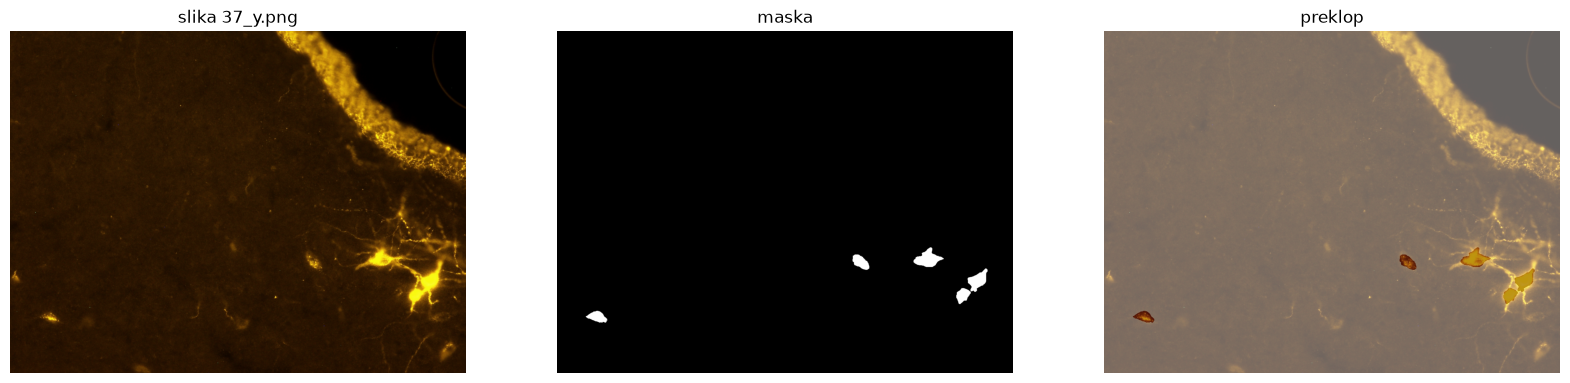

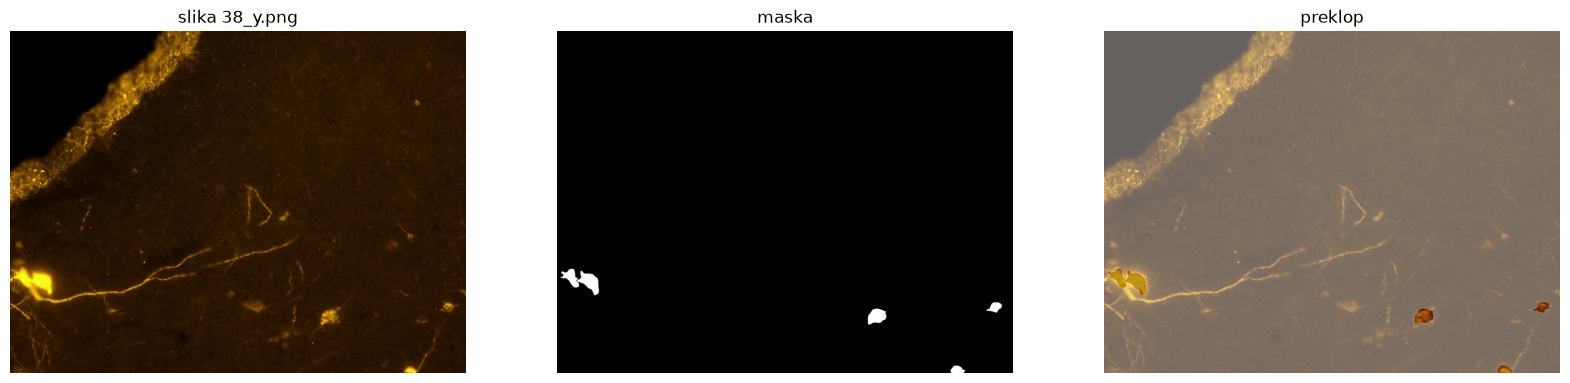

In [5]:
show_image_mask_and_overlay(all_pngs[0])
show_image_mask_and_overlay(all_pngs[1])

## 5. Provera maski

Sada ćemo da pogledamo sadržaj maski.
- Proverićemo dtype.
- Proverićemo koliko različitih vrednosti postoji u svakoj i koje su. Očekujemo da su sve maske binarne sa vrednostima 0 i 255.
- Proverićemo dimenzije svih maski (očekujemo da su sve 1600x1200).
- Proverićemo da li sve maske imaju 1 kanal.
- Proverićemo da li imamo duplikata među maskama.

In [6]:
dtypes = Counter()
for name in imgs:
    a = np.array(Image.open(MASK_DIR/name))
    dtypes[str(a.dtype)] += 1

print("dtype maski     :", dict(dtypes))

dtype maski     : {'uint8': 3, 'uint16': 280}


Primećujemo da opis skupa podataka nije precizan jer je samo 3 maske u uint8 formatu, dok su ostale u uint16.

In [7]:
values, dims, channels, non_binary, empty = Counter(), Counter(), Counter(), [], []
for name in imgs:
    a = np.array(Image.open(MASK_DIR/name))
    dims[a.shape[:2]] += 1
    channels[1 if a.ndim == 2 else a.shape[2]] += 1
    u = np.unique(a)
    if set(u.tolist()) == {0, 255}: values["binarne uint8"] += 1
    elif set(u.tolist()) == {0}: values ["samo 0 (prazne)"] += 1
    elif set(u.tolist()) == {0, 65535}: values["binarne uint16"] += 1
    else:                           values["ostale vrednosti pixela (nebinarne)"] += 1
    if len(u) > 2:
        non_binary.append(name)
    if set(u.tolist()) == {0}:
        empty.append(name)
print("vrednosti maski :", dict(values))
print("dimenzije maski :", dict(dims))
print("broj kanala     :", dict(channels))

vrednosti maski : {'ostale vrednosti pixela (nebinarne)': 20, 'binarne uint8': 1, 'binarne uint16': 212, 'samo 0 (prazne)': 50}
dimenzije maski : {(1200, 1600): 283}
broj kanala     : {1: 283}


Prvo nam je zanimljivo da imamo 50 praznih maski. Trebalo bi da razlučimo da li su te maske pogrešne i predstavljaju nam pogrešne oznake (onda ih treba izbaciti) ili su te slike stvarni negativni primeri.

Sačuvaćemo nazive tih maski u txt fajlu i proveru uraditi tokom EDA.

In [8]:

empty_dir = ROOT/"data"/"prazne"
empty_dir.mkdir(parents=True, exist_ok=True)

with open(empty_dir/"empty_masks.txt", "w") as f:
    f.write(("\n".join(empty)))


Takođe vidimo i da 20 maski nisu binarne, već imaju i druge vrednosti.

Proverićemo detaljnije koliko tih vrednosti ima u svakoj od nebinarnih maski. Proverićemo i da li se te nebinarne maske poklapaju sa listom ručno segmentiranih slika datih u README.md skupa podataka.

In [9]:
manual =  [
    "Mar31bS2C1R2_VLPAGr_200x_y.png",
    "Mar33bS1C4R2_DMl_200x_y.png",
    "Mar40S1C2R2_DMl_200x_o.png",
    "Mar41S3C1R1_DMl_200x_o.png",
    "MAR38S1C3R1_LHR_20_o.png",
    "MAR38S1C3R1_DML_20_o.png",
    "Mar42S2C2R2_DMr_200x_o.png",
    "Mar36bS1C6R2_DMl_200x_y.png",
    "39_y.png",  # ovde sam rucno dodala _y jer ne postoji u datasetu slika 39.png kao sto pise u readme
    "Mar40S1C2R2_DMr_200x_o.png",
    "Mar41S3C1R1_DMr_200x_o.png",
    "Mar33bS2C1R1_DMl_200x_y.png",
    "Mar43S1C5R3_DMr_200x_o.png",
    "Mar37S1C2R1_DMr_200x_o.png",
    "Mar40S3C4R2_VLPAGr_200x_o.png",
    "37_y.png", # ovde sam rucno dodala _y jer ne postoji u datasetu slika 37.png kao sto pise u readme
    "Mar37S1C2R1_DMl_200x_o.png",
    "Mar36bS1C6R2_DMr_200x_y.png",
    "MAR55S3C2R2_VLPAGL_20_o.png",
    "MAR39S2C2R2_DMR_200x_o.png",
    "38_y.png", # ovde sam rucno dodala _y jer ne postoji u datasetu slika 38.png kao sto pise u readme
    "MAR55S3C2R2_VLPAGR_20_o.png",
    "Mar31bS2C3R4_DMr_200x_y.png",
    "Mar32bS2C2R2_DMl_200x_y.png",
    "MAR39S2C2R2_DML_200x_o.png",
    "MAR52S2C1R3_LHL_20_o.png",
    "Mar42S2C4R2_VLPAGr_200x_o.png",
    "MAR55S1C5R3_DMR_20_o.png",
    "MAR38S1C3R1_DMR_20_o.png",
    "Mar33bS1C4R2_DMr_200x_y.png",
    "Mar41S3C3R3_VLPAGl_200x_o.png",
]

In [10]:
print("sve nebinarne su u 'manual':", set(non_binary) <= set(manual))
print("nebinarne van 'manual':", set(non_binary) - set(manual))

# udeo međuvrednosti u nebinarnim maskama
print("\nudeo međuvrednosti (0 < v < max) u nenultim pikselima:")
udeli = []
for name in non_binary:
    a = np.array(Image.open(MASK_DIR/name))
    nz = int((a > 0).sum()); mid = int(((a > 0) & (a < a.max())).sum())
    udeo = 100*mid/nz
    udeli.append(udeo)
    print(f"  {name:<42} {mid:>6}/{nz:<7} = {udeo:5.2f}%")

print(f"\nprosečan udeo međuvrednosti: {np.mean(udeli):.2f}%")

sve nebinarne su u 'manual': True
nebinarne van 'manual': set()

udeo međuvrednosti (0 < v < max) u nenultim pikselima:
  37_y.png                                       18/12664   =  0.14%
  39_y.png                                        4/8817    =  0.05%
  MAR38S1C3R1_DML_20_o.png                      129/39436   =  0.33%
  MAR38S1C3R1_DMR_20_o.png                      304/46344   =  0.66%
  MAR39S2C2R2_DML_200x_o.png                     55/15489   =  0.36%
  MAR39S2C2R2_DMR_200x_o.png                    114/18443   =  0.62%
  MAR52S2C1R3_LHL_20_o.png                      694/24224   =  2.86%
  MAR55S3C2R2_VLPAGL_20_o.png                   460/13775   =  3.34%
  MAR55S3C2R2_VLPAGR_20_o.png                   890/17673   =  5.04%
  Mar33bS1C4R2_DMr_200x_y.png                   156/27357   =  0.57%
  Mar36bS1C6R2_DMl_200x_y.png                   274/65644   =  0.42%
  Mar37S1C2R1_DMl_200x_o.png                    283/37744   =  0.75%
  Mar37S1C2R1_DMr_200x_o.png                    319/

Sve nebinarne maske su iz ručno segmentiranog podskupa. Najverovatnije objašnjenje je da ručno crtane granice, kad se sačuvaju, imaju blago
omekšanu (sivu) ivicu, dok automatski postupak daje samo čisto crno/belo.

Iz ovog ispitivanja možemo da izvedemo strategiju za binarizaciju maski: 0 je 0, a 1 je svaki piksel >0.

Na kraju sekcije proveravamo duplikate među maskama. To radimo računanjem md5 nad sadržajem piksela
(ne nad bajtovima fajla), i to nad već binarizovanom maskom (`>0`), pa duplikat hvatamo i kad se
dtype/kodiranje razlikuju (uint8 vs uint16). Ovo je provera kvaliteta oznaka (da neka maska nije
greškom iskopirana na više slika).

In [11]:
import hashlib

def md5_array(a):
    return hashlib.md5(np.ascontiguousarray(a)).hexdigest()

mask_groups = {}
for name in imgs:
    a = np.array(Image.open(MASK_DIR/name))
    mask_groups.setdefault(md5_array(a > 0), []).append(name)   # poredimo binarizovan sadržaj

dup_masks = {h: names for h, names in mask_groups.items() if len(names) > 1}
print("jedinstvenih maski (po sadržaju):", len(mask_groups), "od", len(imgs))
print("grupa duplikata među maskama    :", len(dup_masks))
for names in dup_masks.values():
    tip = "prazne" if names[0] in empty else "nisu prazne"
    prikaz = ", ".join(names[:4]) + (" ..." if len(names) > 4 else "")
    print(f"  {len(names):>3} maski ({tip}): {prikaz}")

jedinstvenih maski (po sadržaju): 233 od 283
grupa duplikata među maskama    : 2
   50 maski (prazne): Mar19bS1C1R3_VLPAGl_200x_y.png, Mar19bS1C2R2_VLPAGl_200x_y.png, Mar19bS1C3R1_VLPAGl_200x_y.png, Mar19bS1C5R3_DMr_200x_y.png ...
    2 maski (nisu prazne): Mar19bS1C4R2_DMr_200x_y.png, Mar26bS2C2R3_LHl_200x_y.png


Duplikati postoje u dve grupe:

1. **Prazne maske** — očekivano (sve nule); nije nalaz o kvalitetu oznaka nego posledica toga što deo
   slika nema nijednu ćeliju.
2. **Maske sa identičnim sadržajem koje nisu prazne** — netrivijalno: dve različite stavke nose istu oznaku.
   Ovu grupu odmah ispitujemo ispod, a konačan zaključak ćemo doneti nakon provere
   duplikata slika.

In [16]:
# veličina objekta u dupliaranoj maski koja niije prazna
for names in dup_masks.values():
    if names[0] not in empty:
        m = np.array(Image.open(MASK_DIR/names[0])) > 0
        lab, n_obj = ndimage.label(m)
        sizes = sorted(np.bincount(lab.ravel())[1:].tolist())
        print(names, "-> broj objekata:", n_obj, "| veličine px:", sizes)

['Mar19bS1C4R2_DMr_200x_y.png', 'Mar26bS2C2R3_LHl_200x_y.png'] -> broj objekata: 1 | veličine px: [41]


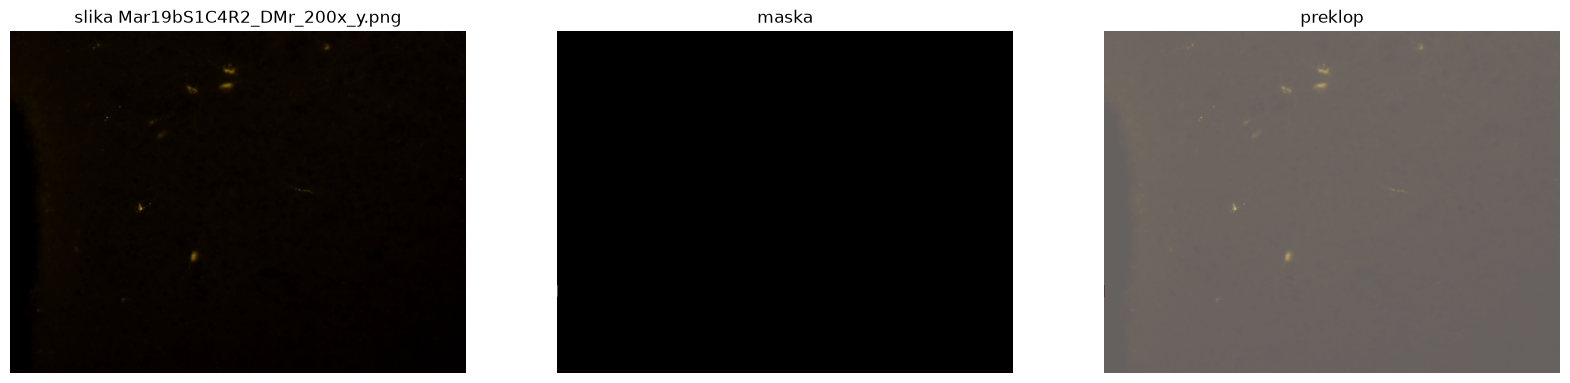

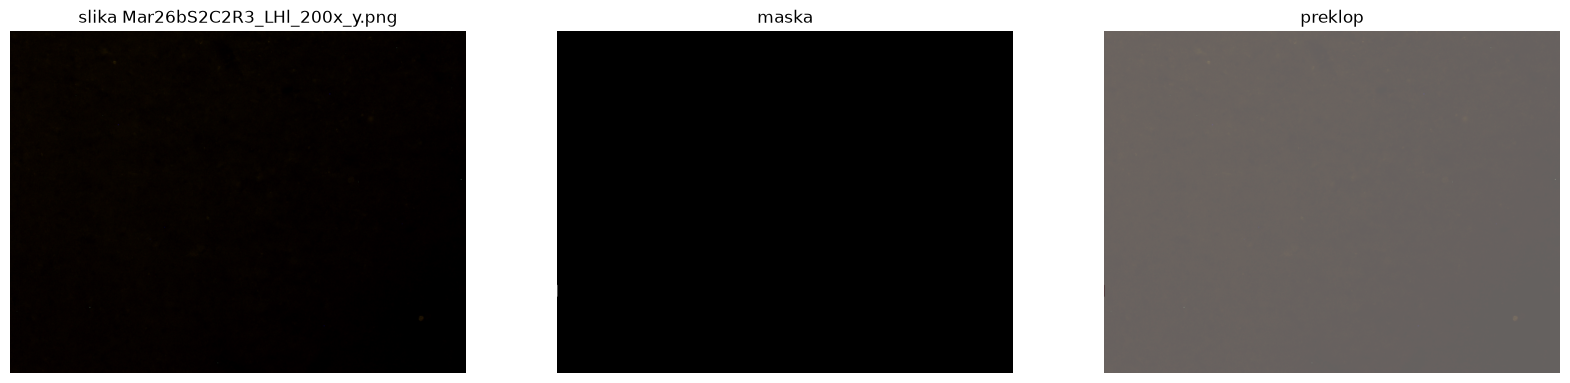

In [22]:
nonempty_dups = ['Mar19bS1C4R2_DMr_200x_y.png', 'Mar26bS2C2R3_LHl_200x_y.png']
show_image_mask_and_overlay(nonempty_dups[0])
show_image_mask_and_overlay(nonempty_dups[1])


## 6. Provera slika
- Proverićemo dtype.
- Proverićemo dimenzije svih slika (očekujemo da su sve 1600x1200).
- Proverićemo da li sve slike imaju 3 kanala.
- Proverićemo da li imamo duplikata među slikama.

In [13]:
img_dtypes, img_dims, img_channels, img_modes = Counter(), Counter(), Counter(), Counter()
img_groups, ranges = {}, []

for name in imgs:
    im = Image.open(IMG_DIR/name)
    a = np.array(im)
    img_modes[im.mode] += 1
    img_dtypes[str(a.dtype)] += 1
    img_dims[a.shape[:2]] += 1
    img_channels[1 if a.ndim == 2 else a.shape[2]] += 1
    ranges.append((int(a.min()), int(a.max())))
    img_groups.setdefault(md5_array(a), []).append(name)

print("mode slika      :", dict(img_modes))
print("dtype slika     :", dict(img_dtypes))
print("dimenzije slika :", dict(img_dims))
print("broj kanala     :", dict(img_channels))
print("opseg vrednosti : min =", min(r[0] for r in ranges), "max =", max(r[1] for r in ranges))

dup_imgs = {h: names for h, names in img_groups.items() if len(names) > 1}
print("\njedinstvenih slika (po sadržaju):", len(img_groups), "od", len(imgs))
print("grupa duplikata među slikama    :", len(dup_imgs))
for names in dup_imgs.values():
    print("  ", names)

mode slika      : {'RGB': 283}
dtype slika     : {'uint8': 283}
dimenzije slika : {(1200, 1600): 283}
broj kanala     : {3: 283}
opseg vrednosti : min = 0 max = 255

jedinstvenih slika (po sadržaju): 283 od 283
grupa duplikata među slikama    : 0


Slike su, za razliku od maski, potpuno konzistentne sa opisom dataseta: svih 283 su RGB uint8,
dimenzija 1600×1200, sa 3 kanala i vrednostima u punom opsegu 0-255. Duplikata nema i svih 283 slika
je jedinstveno po sadržaju piksela, pa nema rizika da ista slika završi i u train i u test skupu.
Jedini duplikat u podacima je na strani oznaka.

Pronađena je jedna grupa od 2 neprazne maske sa identičnim sadržajem
(`Mar19bS1C4R2_DMr_200x_y.png` i `Mar26bS2C2R3_LHl_200x_y.png`). Provera duplikata nad slikama
nije našla nijedan identičan par. Dakle, to nisu duplirani inputi. Ručno su otvorene obe
slike i potvrđeno je da su evidentno različite, a identična maska je verovatno slučajnost jer
maska sadrži samo jedan sitan objekat od 41 px, pa se lako poklopi.

Napomena: 41 px je blizu praga od 40px za uklanjanje sitnih komponenti pri brojanju koji je dat u radu koji je osnova teme projekta, pa te dve slike
mogu završiti kao slike sa 0 ćelija.

Zaključak: ova pojava je benigna i ne preduzimamo ništa, obe slike zadržavamo.